In [2]:
# =========================================================
# 0️⃣ INSTALL DEPENDENCIES
# =========================================================
!pip install -q timm albumentations==1.3.1 roboflow opencv-python

# =========================================================
# 1️⃣ IMPORTS & SETUP
# =========================================================
import os, glob, random
import numpy as np
from collections import Counter
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import timm
from roboflow import Roboflow

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
print("🔥 Device:", device)

# =========================================================
# 2️⃣ DOWNLOAD DATASET
# =========================================================
rf = Roboflow(api_key="I2du50GUFMWkImaaH0Wm")
project = rf.workspace("ahsan-khan-iw5ip").project("blood-group-detection-kmolp")
dataset = project.version(1).download("folder")
dataset_path = dataset.location

# =========================================================
# 3️⃣ LOAD DATA & SPLIT
# =========================================================
def load_all_data(path):
    files, labels = [], []
    classes = sorted(os.listdir(os.path.join(path, "train")))
    for i, cls in enumerate(classes):
        for split in ["train", "valid", "test"]:
            p = os.path.join(path, split, cls)
            if os.path.exists(p):
                imgs = glob.glob(p + "/*")
                files.extend(imgs)
                labels.extend([i] * len(imgs))
    return files, labels, classes

files, labels, classes = load_all_data(dataset_path)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    files, labels, test_size=0.30, stratify=labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42
)

cnt = Counter(y_train)
print("📊 Train Distribution:", cnt)

# =========================================================
# 4️⃣ AUGMENTATION (FINGERPRINT SAFE)
# =========================================================
train_tfms = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=8, p=0.3),
    A.Normalize(),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2()
])

# =========================================================
# 5️⃣ DATASET & DATALOADERS
# =========================================================
class FingerprintDataset(Dataset):
    def __init__(self, files, labels, tfm):
        self.files = files
        self.labels = labels
        self.tfm = tfm

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.files[idx]).convert("RGB"))
        img = self.tfm(image=img)["image"]
        return img, torch.tensor(self.labels[idx])

weights = [1.0 / cnt[l] for l in y_train]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_dl = DataLoader(
    FingerprintDataset(X_train, y_train, train_tfms),
    batch_size=32, sampler=sampler, num_workers=2
)

val_dl = DataLoader(
    FingerprintDataset(X_val, y_val, val_tfms),
    batch_size=64, num_workers=2
)

test_dl = DataLoader(
    FingerprintDataset(X_test, y_test, val_tfms),
    batch_size=64, num_workers=2
)

# =========================================================
# 6️⃣ MODEL — ConvNeXt Tiny
# =========================================================
model = timm.create_model(
    "convnext_tiny",
    pretrained=True,
    num_classes=len(classes)
).to(device)

print("✅ ConvNeXt-Tiny Loaded")

# =========================================================
# 7️⃣ LOSS, OPTIMIZER & SCHEDULER
# =========================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=25
)

scaler = torch.cuda.amp.GradScaler()

# =========================================================
# 8️⃣ CUTMIX FUNCTION
# =========================================================
def cutmix(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(x.size(0)).to(device)
    y_a, y_b = y, y[rand_index]
    h = int(x.size(2) * lam)
    x[:, :, :h, :] = x[rand_index, :, :h, :]
    lam = 1 - h / x.size(2)
    return x, y_a, y_b, lam

# =========================================================
# 9️⃣ TRAINING (LOSS + LR DISPLAY)
# =========================================================
EPOCHS = 25
best_val = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    tp, ty = [], []

    for x, y in tqdm(train_dl, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        if random.random() < 0.5:
            x, y_a, y_b, lam = cutmix(x, y)
            with torch.cuda.amp.autocast():
                out = model(x)
                loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
        else:
            with torch.cuda.amp.autocast():
                out = model(x)
                loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        tp += out.argmax(1).cpu().tolist()
        ty += y.cpu().tolist()

    scheduler.step()
    lr = optimizer.param_groups[0]["lr"]
    tr_acc = accuracy_score(ty, tp)
    train_loss /= len(train_dl)

    # ---------------- VALIDATION ----------------
    model.eval()
    val_loss = 0
    vp, vy = [], []

    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()
            vp += out.argmax(1).cpu().tolist()
            vy += y.cpu().tolist()

    val_loss /= len(val_dl)
    v_acc = accuracy_score(vy, vp)

    print(
        f"📊 Epoch {epoch+1} | "
        f"LR={lr:.6f} | "
        f"Train Loss={train_loss:.4f} | "
        f"Val Loss={val_loss:.4f} | "
        f"Train Acc={tr_acc:.4f} | "
        f"Val Acc={v_acc:.4f}"
    )

    if v_acc > best_val:
        best_val = v_acc
        torch.save(model.state_dict(), "Best_ConvNeXt_Tiny.pth")
        print("✅ Best model saved")

# =========================================================
# 🔟 TESTING
# =========================================================
model.load_state_dict(torch.load("Best_ConvNeXt_Tiny.pth"))
model.eval()

tp, ty = [], []
with torch.no_grad():
    for x, y in test_dl:
        x, y = x.to(device), y.to(device)
        out = model(x)
        tp += out.argmax(1).cpu().tolist()
        ty += y.cpu().tolist()

print("\n🎯 TEST ACCURACY:", accuracy_score(ty, tp))
print("\n📄 CLASSIFICATION REPORT:\n")
print(classification_report(ty, tp, target_names=classes))

# =========================================================
# ✅ SAVE FINAL MODEL
# =========================================================
torch.save(model.state_dict(), "ConvNeXt_Tiny_Final.pth")
print("✅ Final model saved")


🔥 Device: cuda
loading Roboflow workspace...
loading Roboflow project...
📊 Train Distribution: Counter({1: 1679, 6: 1410, 3: 1281, 5: 1266, 7: 1192, 2: 1185, 4: 1088, 0: 954})
✅ ConvNeXt-Tiny Loaded


`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.


Epoch 1/25:   0%|          | 0/315 [00:00<?, ?it/s]

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


📊 Epoch 1 | LR=0.000299 | Train Loss=1.9973 | Val Loss=1.6199 | Train Acc=0.1945 | Val Acc=0.3383
✅ Best model saved


...

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


📊 Epoch 24 | LR=0.000001 | Train Loss=0.7413 | Val Loss=0.5395 | Train Acc=0.7649 | Val Acc=0.9703
✅ Best model saved


Epoch 25/25:   0%|          | 0/315 [00:00<?, ?it/s]

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


📊 Epoch 25 | LR=0.000000 | Train Loss=0.7105 | Val Loss=0.5387 | Train Acc=0.7942 | Val Acc=0.9698

🎯 TEST ACCURACY: 0.9721577726218097

📄 CLASSIFICATION REPORT:

              precision    recall  f1-score   support

          A+       0.99      0.97      0.98       204
          A-       0.97      0.97      0.97       359
         AB+       0.96      0.98      0.97       254
         AB-       0.97      0.97      0.97       275
          B+       1.00      0.97      0.98       233
          B-       0.99      0.99      0.99       272
          O+       0.95      0.97      0.96       303
          O-       0.96      0.95      0.95       255

    accuracy                           0.97      2155
   macro avg       0.97      0.97      0.97      2155
weighted avg       0.97      0.97      0.97      2155

✅ Final model saved


🚀 Generating conference / journal reports...


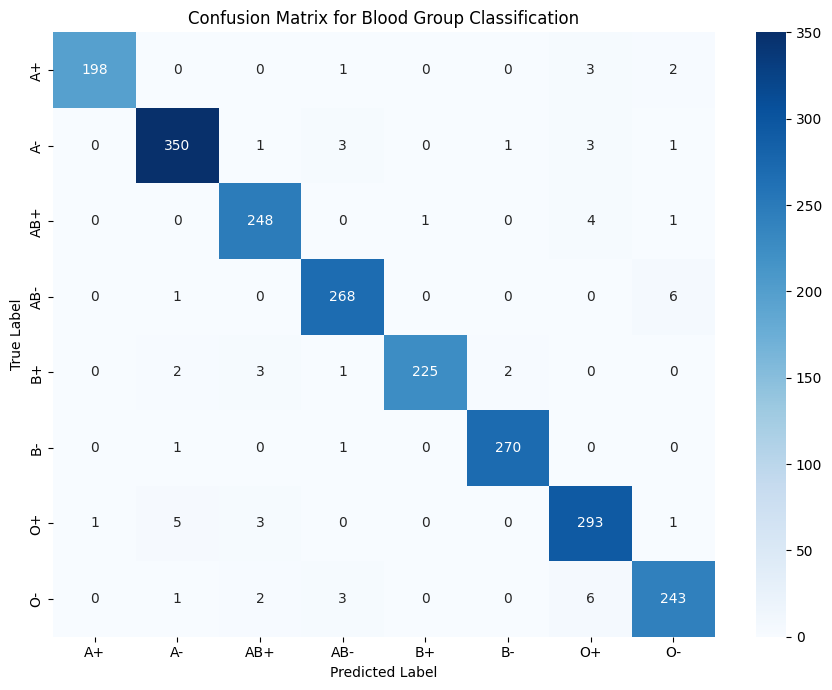


📄 Classification Report:

              precision    recall  f1-score   support

          A+       0.99      0.97      0.98       204
          A-       0.97      0.97      0.97       359
         AB+       0.96      0.98      0.97       254
         AB-       0.97      0.97      0.97       275
          B+       1.00      0.97      0.98       233
          B-       0.99      0.99      0.99       272
          O+       0.95      0.97      0.96       303
          O-       0.96      0.95      0.95       255

    accuracy                           0.97      2155
   macro avg       0.97      0.97      0.97      2155
weighted avg       0.97      0.97      0.97      2155


📊 Metrics Summary:

               Accuracy  Precision (Weighted)  Recall (Weighted)  \
ConvNeXt-Tiny  0.972158              0.972353           0.972158   

               F1-score (Weighted)  
ConvNeXt-Tiny             0.972197  

⚙️ Model Parameters
Total Parameters: 27826280
Trainable Parameters: 27826280

⏱️ Inferen

In [7]:
# =========================================================
# 📊 FINAL REPORT GENERATION (NO RETRAINING REQUIRED)
# =========================================================

import os
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("🚀 Generating conference / journal reports...")

# =========================================================
# 1️⃣ CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(ty, tp)

plt.figure(figsize=(9,7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Blood Group Classification")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

# =========================================================
# 2️⃣ CLASSIFICATION REPORT (TXT)
# =========================================================
report = classification_report(ty, tp, target_names=classes)
print("\n📄 Classification Report:\n")
print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)

# =========================================================
# 3️⃣ METRICS SUMMARY (CSV – PAPER TABLE)
# =========================================================
metrics = {
    "Accuracy": accuracy_score(ty, tp),
    "Precision (Weighted)": precision_score(ty, tp, average="weighted"),
    "Recall (Weighted)": recall_score(ty, tp, average="weighted"),
    "F1-score (Weighted)": f1_score(ty, tp, average="weighted"),
}

metrics_df = pd.DataFrame(metrics, index=["ConvNeXt-Tiny"])
metrics_df.to_csv("metrics_summary.csv")
print("\n📊 Metrics Summary:\n")
print(metrics_df)

# =========================================================
# 4️⃣ MODEL COMPLEXITY (TXT)
# =========================================================
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

with open("model_parameters.txt", "w") as f:
    f.write(f"Model: ConvNeXt-Tiny\n")
    f.write(f"Total Parameters: {total_params}\n")
    f.write(f"Trainable Parameters: {trainable_params}\n")

print("\n⚙️ Model Parameters")
print("Total Parameters:", total_params)
print("Trainable Parameters:", trainable_params)

# =========================================================
# 5️⃣ INFERENCE TIME (TXT)
# =========================================================
model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Warm-up
for _ in range(10):
    _ = model(dummy_input)

start = time.time()
for _ in range(100):
    _ = model(dummy_input)
end = time.time()

avg_inference_time = (end - start) / 100

with open("inference_time.txt", "w") as f:
    f.write(f"Average inference time per image: {avg_inference_time:.6f} seconds\n")

print("\n⏱️ Inference Time per Image:", avg_inference_time, "seconds")

# =========================================================
# 6️⃣ FINAL CONFIRMATION
# =========================================================
print("\n✅ ALL FILES GENERATED SUCCESSFULLY")
print("📁 Ready for IEEE / Springer / Elsevier submission")
